In [1]:
import pandas as pd

calendar = pd.read_csv('Data/calendar.csv')
items = pd.read_csv('Data/items_per_season.csv')
customers_fy_16_17 = pd.read_csv('Data/customers_fy_16_17.csv')
customers_fy_23_24 = pd.read_csv('Data/customers_fy_23_24.csv')
items_2016 = pd.read_csv('Data/items_2016.csv')
items_2022 = pd.read_csv('Data/items_2022.csv')
orders_fy_16_17 = pd.read_csv('Data/order_invoice_refunds_fy_16_17.csv')
orders_fy_22_23 = pd.read_csv('Data/order_invoice_refunds_fy_22_23.csv')

In [2]:
# hier stehen die echten Spaltennamen in Row 0
items = pd.read_csv("Data/items_per_season.csv", skiprows=1, names=["ITEM_NO", "SEASON", "IS_CURRENT_SEASON", "ITEM_END_DATE", "SEASON_START_DATE", "SEASON_END_DATE", "PRODUCT_STATUS_PER_SEASON", "IS_ACTIVE_IN_SEASON"])
items = items.drop(index=0).reset_index(drop=True)
print(items.columns.tolist())
display(items.head())

['ITEM_NO', 'SEASON', 'IS_CURRENT_SEASON', 'ITEM_END_DATE', 'SEASON_START_DATE', 'SEASON_END_DATE', 'PRODUCT_STATUS_PER_SEASON', 'IS_ACTIVE_IN_SEASON']


,ITEM_NO,SEASON,IS_CURRENT_SEASON,ITEM_END_DATE,SEASON_START_DATE,SEASON_END_DATE,PRODUCT_STATUS_PER_SEASON,IS_ACTIVE_IN_SEASON
0,0-01356-70111-10,SS_2026,TRUE,NaN,2026-02-01,2027-01-31,Other,TRUE
1,01395-20151-680,SS_2027,FALSE,NaN,2027-01-01,2027-12-31,old - previous season,FALSE
2,AFZ-SHP-125-828,AW_2025_2026,FALSE,2023-06-29,2025-07-01,2025-11-30,old - older than previous season,FALSE
3,8223267700327011,AW_2026_2027,FALSE,NaN,NaN,NaN,old - older than previous season,FALSE
4,0-AFZ-SHP-124-410,SS_2027,FALSE,NaN,2027-02-01,2028-01-31,Other,TRUE


In [3]:
orders = pd.concat([orders_fy_16_17, orders_fy_22_23], ignore_index=True)
items_list = pd.concat([items_2016, items_2022], ignore_index=True)


In [4]:
print(type(items))
print(items.shape)
print(items.columns.tolist())

# Spalten sicher säubern
items.columns = items.columns.astype(str).str.strip()
items_list.columns = items_list.columns.astype(str).str.strip()

# Join-Key säubern
items["ITEM_NO"] = items["ITEM_NO"].astype(str).str.strip()
items_list["ITEM_NO"] = items_list["ITEM_NO"].astype(str).str.strip()

# gewünschte Spalten auswählen
cols = ["ITEM_NO", "SEASON", "ITEM_END_DATE", "SEASON_START_DATE", "SEASON_END_DATE"]

items_add = items.loc[:, cols].copy()

# falls ITEM_NO mehrfach vorkommt:
items_add = items_add.drop_duplicates(subset=["ITEM_NO"])

items_full = items_list.merge(
    items_add,
    how="left",
    on="ITEM_NO"
)

display(items_full.head())

<class 'pandas.core.frame.DataFrame'>
(27444, 8)
['ITEM_NO', 'SEASON', 'IS_CURRENT_SEASON', 'ITEM_END_DATE', 'SEASON_START_DATE', 'SEASON_END_DATE', 'PRODUCT_STATUS_PER_SEASON', 'IS_ACTIVE_IN_SEASON']


,ITEM_NO,ITEM_NO_PREDECESSOR_1,ITEM_NO_PREDECESSOR_2,BRAND,MAIN_CATEGORY,SUB_CATEGORY,PRODUCT_TYPE,MATERIAL,SIZE,CATEGORY_KEY,PLANNING_CATEGORY_KEY,APPEARANCE,APPEARANCE_EN,CURRENT_PRODUCT_STATUS,SEASON,ITEM_END_DATE,SEASON_START_DATE,SEASON_END_DATE
0,AFZ-SKN-128-20083,NaN,NaN,AFFENZAHN,FOOTWEAR,LOWCUTS,HAPPY,POLYESTER KNIT,28,AFFENZAHN~FOOTWEAR~LOWCUTS~HAPPY,AFFENZAHN~FOOTWEAR~LOWCUTS~HAPPY~~,DRAGON,NaN,old - older than previous season,SS_2027,NaN,2027-01-01,2027-12-31
1,AFZ-SES-129-001,NaN,NaN,AFFENZAHN,FOOTWEAR ACC,INSERT SOLES,INSERT SOLES,POLYESTER,29,AFFENZAHN~FOOTWEAR ACC~INSERT SOLES~INSERT SOLES,AFFENZAHN~FOOTWEAR ACC~INSERT SOLES~INSERT SOL...,TIGER,NaN,old - older than previous season,SS_2027,NaN,NaN,NaN
2,AFZ-FAS-004-001,NaN,NaN,AFFENZAHN,BAGS,BACKPACKS,SMALL FRIEND,POLYESTER CANVAS,onesize,AFFENZAHN~BAGS~BACKPACKS~SMALL FRIEND,AFFENZAHN~BAGS~BACKPACKS~SMALL FRIEND~~,Tiger,Tiger,old - previous season,SS_2025,2026-01-30,2025-02-01,2026-01-31
3,AFZ-FAS-004-001,NaN,NaN,AFFENZAHN,BAGS,BACKPACKS,SMALL FRIEND,POLYESTER CANVAS,onesize,AFFENZAHN~BAGS~BACKPACKS~SMALL FRIEND,AFFENZAHN~BAGS~BACKPACKS~SMALL FRIEND~~,Tiger,Tiger,old - previous season,SS_2025,2026-01-30,2025-02-01,2026-01-31
4,AFZ-FAS-002-002,NaN,NaN,AFFENZAHN,BAGS,BACKPACKS,SMALL FRIEND,POLYESTER,onesize,AFFENZAHN~BAGS~BACKPACKS~SMALL FRIEND,AFFENZAHN~BAGS~BACKPACKS~SMALL FRIEND~~,Löwe,Lion,old - older than previous season,SS_2025,2023-01-30,2025-02-01,2026-01-31


In [5]:
print("orders:", orders.shape)
items_lookup = items_full[
    ["ITEM_NO", "MAIN_CATEGORY", "SUB_CATEGORY", "PRODUCT_TYPE", "SIZE", "APPEARANCE", "SEASON", "ITEM_END_DATE", "SEASON_START_DATE", "SEASON_END_DATE"]   # hier deine gewünschten Spalten ergänzen
]
print("items_lookup:", items_lookup.shape)

print("Doppelte ITEM_NO in items_lookup:")
print(items_lookup["ITEM_NO"].duplicated().sum())

print(items_lookup["ITEM_NO"].value_counts().head(10))

orders: (1964146, 22)
items_lookup: (1970027, 10)
Doppelte ITEM_NO in items_lookup:
1964770
ITEM_NO
AFZ-FAS-004-001    11466
AFZ-BOT-001-347     6703
AFZ-FAS-002-002     6037
AFZ-FAS-002-009     5699
AFZ-FAL-002-005     5674
AFZ-FAS-001-029     4757
AFZ-FAS-001-026     4265
AFZ-BOT-001-006     4217
AFZ-FAS-001-021     4064
AFZ-FAS-002-003     3934
Name: count, dtype: int64


In [6]:
items_lookup = items_lookup.drop_duplicates(subset=["ITEM_NO"])

In [7]:
orders_item = orders.merge(
    items_lookup,
    how="left",
    on="ITEM_NO",
    validate="many_to_one"
)

orders_item = orders_item.sort_values(["ORDER_NO", "LINE_NO"])

display(orders_item.head())

,ITEM_NO,DOCUMENT_NO,LINE_NO,ORDER_DATE,ORDER_NO,POSTING_DATE,COUNTRY_CODE,CUSTOMER_NO,QUANTITY,NET_AMOUNT,...,SEASON_POSTING_DATE,MAIN_CATEGORY,SUB_CATEGORY,PRODUCT_TYPE,SIZE,APPEARANCE,SEASON,ITEM_END_DATE,SEASON_START_DATE,SEASON_END_DATE
11174,HAP-SIN-001-007,RG1732378,10000.0,2016-12-28,-missing-,2016-12-28,AT,D116611,1,29.08,...,NaN,BAGS,BACKPACKS,SMALL FRIEND,NaN,DOG,NaN,NaN,NaN,NaN
30470,AFZ-FAL-001-002,RG1732380,10000.0,2016-12-28,-missing-,2016-12-28,AT,D119475,1,41.58,...,NaN,BAGS,BACKPACKS,LARGE FRIEND,NaN,ELEPHANT,NaN,NaN,NaN,NaN
58189,AFZ-FAL-001-005,RG1732273,10000.0,2016-12-28,-missing-,2016-12-28,AT,D116611,1,41.58,...,NaN,BAGS,BACKPACKS,LARGE FRIEND,NaN,TIGER,NaN,NaN,NaN,NaN
77685,AFZ-FAS-001-007,RG1732580,10000.0,2016-12-28,-missing-,2016-12-28,AT,D123776,1,29.08,...,NaN,BAGS,BACKPACKS,SMALL FRIEND,NaN,FOX,NaN,NaN,NaN,NaN
91026,AFZ-FAL-001-009,RG1732257,10000.0,2016-12-28,-missing-,2016-12-28,AT,D115966,1,41.59,...,NaN,BAGS,BACKPACKS,LARGE FRIEND,NaN,ZEBRA,NaN,NaN,NaN,NaN


In [8]:
display(orders_item.tail())

,ITEM_NO,DOCUMENT_NO,LINE_NO,ORDER_DATE,ORDER_NO,POSTING_DATE,COUNTRY_CODE,CUSTOMER_NO,QUANTITY,NET_AMOUNT,...,SEASON_POSTING_DATE,MAIN_CATEGORY,SUB_CATEGORY,PRODUCT_TYPE,SIZE,APPEARANCE,SEASON,ITEM_END_DATE,SEASON_START_DATE,SEASON_END_DATE
146838,AFZ-SKR-002-010,GU1819-19006800,70000.0,NaN,NaN,2019-01-08,GB,D261358,-1,-29.33,...,NaN,FOOTWEAR,BABYSHOES,SOFT SHOES,M,OWL,NaN,NaN,NaN,NaN
586837,AFZ-FAL-001-007,GU1819-19006800,80000.0,NaN,NaN,2019-01-08,GB,D261358,-1,-41.93,...,SS_2018,BAGS,BACKPACKS,LARGE FRIEND,NaN,FOX,NaN,NaN,NaN,NaN
357640,AFZ-SMB-127-410,GU1920-20004379,90000.0,NaN,NaN,2019-10-24,DE,D370971,-1,-45.33,...,NaN,FOOTWEAR,MIDBOOTS,COMFY,27,BIRD,NaN,NaN,NaN,NaN
150638,AFZ-SMB-128-410,GU1920-20004379,100000.0,NaN,NaN,2019-10-24,DE,D370971,-1,-45.33,...,NaN,FOOTWEAR,MIDBOOTS,COMFY,28,BIRD,NaN,NaN,NaN,NaN
1094021,AFZ-SCF-002-001,GU2223-00024708,130000.0,NaN,NaN,2022-11-29,DE,D396378,-1,-20.92,...,SS_2022,APPAREL ACC,SCARVES,SCARF,NaN,TIGER,NaN,NaN,NaN,NaN


In [9]:
print("unique order no:", orders_item["ORDER_NO"].nunique())
# echte NaN
print("NaN:", orders_item["ORDER_NO"].isna().sum())

# String "Missing"
print("String Missing:", (orders_item["ORDER_NO"] == "-missing-").sum())

unique order no: 965302
NaN: 30
String Missing: 2453


In [10]:
orders_item["ORDER_NO"] = orders_item["ORDER_NO"].replace("-missing-", pd.NA)
print("NaN:", orders_item["ORDER_NO"].isna().sum())

# String "Missing"
print("String Missing:", (orders_item["ORDER_NO"] == "-missing-").sum())

NaN: 2483
String Missing: 0


In [11]:
orders_item = orders_item.sort_values(["ITEM_NO", "DOCUMENT_NO"])
display(orders_item.head())

,ITEM_NO,DOCUMENT_NO,LINE_NO,ORDER_DATE,ORDER_NO,POSTING_DATE,COUNTRY_CODE,CUSTOMER_NO,QUANTITY,NET_AMOUNT,...,SEASON_POSTING_DATE,MAIN_CATEGORY,SUB_CATEGORY,PRODUCT_TYPE,SIZE,APPEARANCE,SEASON,ITEM_END_DATE,SEASON_START_DATE,SEASON_END_DATE
1789823,00390-30125-650,GU2223-00040372,30000.0,2023-02-22,AU2223-00293305,2023-03-03,DE,D1304839,-1,-58.82,...,SS_2023,FOOTWEAR,LOWCUTS,WALKER,19,Schildkröte,SS_2027,2025-01-30,2027-01-01,2027-12-31
1921076,00390-30125-650,GU2223-00040502,60000.0,2023-02-20,AU2223-00290555,2023-03-06,DE,D636749,-1,-58.82,...,SS_2023,FOOTWEAR,LOWCUTS,WALKER,19,Schildkröte,SS_2027,2025-01-30,2027-01-01,2027-12-31
1722419,00390-30125-650,GU2223-00046227,30000.0,2023-03-20,AU2223-00326841,2023-04-06,DE,D1306201,-1,-58.82,...,SS_2023,FOOTWEAR,LOWCUTS,WALKER,19,Schildkröte,SS_2027,2025-01-30,2027-01-01,2027-12-31
1503058,00390-30125-650,GU2223-00049085,30000.0,2023-03-23,AU2223-00333815,2023-04-18,DE,D988491,-1,-58.82,...,SS_2023,FOOTWEAR,LOWCUTS,WALKER,19,Schildkröte,SS_2027,2025-01-30,2027-01-01,2027-12-31
1453389,00390-30125-650,GU2223-00050179,30000.0,2023-03-25,AU2223-00338235,2023-04-21,DE,D1328318,-1,-58.82,...,SS_2023,FOOTWEAR,LOWCUTS,WALKER,19,Schildkröte,SS_2027,2025-01-30,2027-01-01,2027-12-31


In [12]:
# 1. Check: Gibt es überhaupt „Matching Retouren“?
orders_item.groupby("ITEM_NO")["QUANTITY"].sum().sort_values().head(20)
# wenn 0, dann wurde alles retourniert

ITEM_NO
01249-20084-670     0
8223264700581008    0
01489-80108-670     0
01636-30119-700     0
01724-80151-720     0
01394-20110-670     0
00397-20001-670     0
01724-20001-690     0
01637-20153-670     0
00392-20187-670     0
01397-20110-670     0
01636-40147-670     1
01636-20153-680     1
01636-30119-670     1
01636-40147-680     1
8223264700327008    1
01724-80151-680     1
01724-30005-690     1
01724-80151-690     1
01394-20110-700     1
Name: QUANTITY, dtype: int64

In [13]:
orders_item["ORDER_NO"].value_counts().head(10)

ORDER_NO
AU2526-00115454    71
AU1920-20091085    60
AU2223-00093618    60
AU2324-00397779    58
AU1920-20125277    56
AU2425-00349016    52
AU2526-00251521    52
AU2425-00059775    51
AU2425-00621373    50
AU2425-00525541    47
Name: count, dtype: int64

In [14]:
orders_item[orders_item["ORDER_NO"] == "AU2425-00525541"].sort_values(["DOCUMENT_NO", "ITEM_NO"]).head(20)

,ITEM_NO,DOCUMENT_NO,LINE_NO,ORDER_DATE,ORDER_NO,POSTING_DATE,COUNTRY_CODE,CUSTOMER_NO,QUANTITY,NET_AMOUNT,...,SEASON_POSTING_DATE,MAIN_CATEGORY,SUB_CATEGORY,PRODUCT_TYPE,SIZE,APPEARANCE,SEASON,ITEM_END_DATE,SEASON_START_DATE,SEASON_END_DATE
653313,01158-20001-780,GU2425-00104121,60000.0,2025-06-03,AU2425-00525541,2025-06-30,DE,D547727,-1,-63.01,...,SS_2025,FOOTWEAR,SANDALS,BREEZY,32,Frosch,SS_2027,NaN,2027-01-01,2027-12-31
859690,01158-30005-690,GU2425-00104121,180000.0,2025-06-03,AU2425-00525541,2025-06-30,DE,D547727,-1,-63.01,...,SS_2025,FOOTWEAR,SANDALS,BREEZY,23,Oktopus,SS_2025,NaN,2025-01-01,2025-12-31
875443,01158-30005-780,GU2425-00104121,30000.0,2025-06-03,AU2425-00525541,2025-06-30,DE,D547727,-1,-63.02,...,SS_2025,FOOTWEAR,SANDALS,BREEZY,32,Oktopus,SS_2027,NaN,2027-01-01,2027-12-31
951799,01158-80028-680,GU2425-00104121,150000.0,2025-06-03,AU2425-00525541,2025-06-30,DE,D547727,-1,-63.02,...,SS_2025,FOOTWEAR,SANDALS,BREEZY,22,Tukan,SS_2026,2026-01-30,2026-01-01,2026-12-31
812105,01158-80028-690,GU2425-00104121,210000.0,2025-06-03,AU2425-00525541,2025-06-30,DE,D547727,-1,-63.02,...,SS_2025,FOOTWEAR,SANDALS,BREEZY,23,Tukan,SS_2024,2026-01-30,2024-01-01,2024-12-31
1548148,01158-80028-770,GU2425-00104121,90000.0,2025-06-03,AU2425-00525541,2025-06-30,DE,D547727,-1,-63.02,...,SS_2025,FOOTWEAR,SANDALS,BREEZY,31,Tukan,SS_2026,2026-01-30,2026-01-01,2026-12-31
750906,01158-80028-780,GU2425-00104121,120000.0,2025-06-03,AU2425-00525541,2025-06-30,DE,D547727,-1,-63.02,...,SS_2025,FOOTWEAR,SANDALS,BREEZY,32,Tukan,SS_2024,2026-01-30,2024-01-01,2024-12-31
1322230,00392-20153-780,GU2425-00104738,120000.0,2025-06-03,AU2425-00525541,2025-06-30,DE,D547727,-1,-54.62,...,SS_2025,FOOTWEAR,SANDALS,AIRY,32,Hase,SS_2027,NaN,2027-01-01,2027-12-31
1431947,00392-30004-780,GU2425-00104738,90000.0,2025-06-03,AU2425-00525541,2025-06-30,DE,D547727,-1,-54.61,...,SS_2025,FOOTWEAR,SANDALS,AIRY,32,Kreativ Bär,SS_2027,2026-01-30,2027-01-01,2027-12-31
1545062,00392-30009-780,GU2425-00104738,150000.0,2025-06-03,AU2425-00525541,2025-06-30,DE,D547727,-1,-54.61,...,SS_2025,FOOTWEAR,SANDALS,AIRY,32,Hai,SS_2027,NaN,2027-01-01,2027-12-31


In [15]:
returns = orders_item[orders_item["QUANTITY"] <= 0]
sales = orders_item[orders_item["QUANTITY"] > 0]

In [18]:
needed_cols = [
    "ORDER_NO", "ITEM_NO", "QUANTITY", "NET_AMOUNT",
    "SEASON", "SEASON_START_DATE", "SEASON_END_DATE",
    "PRODUCT_TYPE", "SIZE", "APPEARANCE", "MAIN_CATEGORY", "SUB_CATEGORY",
    "IS_RETURN_INCL_INDIRECT", "RETURN_REASON_CODE",
    "DAYS_ORDER_TO_INVOICE", "SEASON_ORDER_DATE", "SALES_PRICE_ORIGINAL",
    "SALES_PRICE_INVOICED",
    "UVP"
]

missing_cols = [col for col in needed_cols if col not in orders_item.columns]
print("Fehlende Spalten:", missing_cols)

Fehlende Spalten: []


In [19]:
orders_item["RETURN_REASON_CODE_CLEAN"] = orders_item["RETURN_REASON_CODE"].fillna("")


agg = orders_item.groupby(["ORDER_NO", "ITEM_NO"], sort=False).agg({
    "QUANTITY": "sum",
    "NET_AMOUNT": "sum",
    "SALES_PRICE_ORIGINAL": "mean",
    "SALES_PRICE_INVOICED": "mean",
    "UVP": "mean",
    "INVOICE_DISCOUNT_AMOUNT": "sum",
    "LINE_DISCOUNT_AMOUNT": "sum",
    "SEASON": "first",
    "SEASON_START_DATE": "first",
    "SEASON_END_DATE": "first",
    "PRODUCT_TYPE": "first",
    "SIZE": "first",
    "APPEARANCE": "first",
    "MAIN_CATEGORY": "first",
    "SUB_CATEGORY": "first",
    "IS_RETURN_INCL_INDIRECT": "max",
    "RETURN_REASON_CODE_CLEAN": "max",
    "DAYS_ORDER_TO_INVOICE": "mean",
    "SEASON_ORDER_DATE": "first"
}).reset_index()

In [20]:
(agg["QUANTITY"] < 0).sum()
edge_cases = agg[agg["QUANTITY"] < 0]

# Anteil
print("Anteil an allen Bestellungen:", len(edge_cases) / len(agg))

display(edge_cases.head(20))

agg["EDGE_CASE"] = (agg["QUANTITY"] < 0).astype(int) # markiere für später

Anteil an allen Bestellungen: 0.00015852445948636787


,ORDER_NO,ITEM_NO,QUANTITY,NET_AMOUNT,SALES_PRICE_ORIGINAL,SALES_PRICE_INVOICED,UVP,INVOICE_DISCOUNT_AMOUNT,LINE_DISCOUNT_AMOUNT,SEASON,...,SEASON_END_DATE,PRODUCT_TYPE,SIZE,APPEARANCE,MAIN_CATEGORY,SUB_CATEGORY,IS_RETURN_INCL_INDIRECT,RETURN_REASON_CODE_CLEAN,DAYS_ORDER_TO_INVOICE,SEASON_ORDER_DATE
3289,AU2425-00426500,00391-10025-690,-1,0.00,64.990000,0.000000,64.99,0.0,0.00,SS_2027,...,2027-12-31,LUCKY,23,Tiger,FOOTWEAR,LOWCUTS,False,NF,31.000000,SS_2025
4846,AU2223-00322288,00391-10025-720,-2,-109.22,54.610000,48.058000,64.99,0.0,4.16,SS_2027,...,2027-12-31,LUCKY,26,Tiger,FOOTWEAR,LOWCUTS,True,RET_100,11.800000,SS_2023
9576,AU2425-00426500,00391-10050-690,-1,0.00,64.990000,0.000000,64.99,0.0,0.00,SS_2026,...,2026-12-31,LUCKY,23,Affenzahn 10 Jahre,FOOTWEAR,LOWCUTS,False,NF,31.000000,SS_2025
16408,AU2223-00391128,00391-20110-730,-1,-43.70,54.610000,43.693333,64.99,0.0,-8.85,SS_2026,...,2026-12-31,LUCKY,27,Frosch,FOOTWEAR,LOWCUTS,True,RET_100,4.666667,SS_2023
21361,AU2324-00609142,00391-30001-680,-1,-54.61,54.610000,47.330000,64.99,0.0,2.08,SS_2027,...,2027-12-31,LUCKY,22,Bär,FOOTWEAR,LOWCUTS,True,RET_100,15.000000,SS_2024
24970,AU2425-00427416,00391-30001-720,-1,-54.61,54.610000,54.610000,64.99,0.0,0.00,SS_2025,...,2025-12-31,LUCKY,26,Bär,FOOTWEAR,LOWCUTS,True,RET_100,7.000000,SS_2025
25956,AU2223-00391128,00391-30001-730,-1,-43.69,54.610000,43.690000,64.99,0.0,-8.84,SS_2025,...,2025-12-31,LUCKY,27,Bär,FOOTWEAR,LOWCUTS,True,RET_100,4.666667,SS_2023
46908,AU2425-00629344,00391-40010-720,-1,-43.69,54.610000,43.690000,64.99,0.0,0.00,SS_2025,...,2025-12-31,LUCKY,26,Vogel,FOOTWEAR,LOWCUTS,True,RET_100,8.000000,SS_2025
49912,AU2324-00387146,00391-40010-740,-1,-43.69,54.610000,50.970000,64.99,0.0,-10.92,SS_2027,...,2027-12-31,LUCKY,28,Vogel,FOOTWEAR,LOWCUTS,False,,18.000000,SS_2024
52916,AU2425-00427416,00391-40010-760,-1,-54.61,54.610000,54.610000,64.99,0.0,0.00,SS_2023,...,2023-12-31,LUCKY,30,Vogel,FOOTWEAR,LOWCUTS,True,RET_100,7.000000,SS_2025


In [21]:
agg_clean = agg[agg["QUANTITY"] >= 0]

In [22]:
# Return Variable
agg["RETURNED"] = (agg["QUANTITY"] <= 0).astype(int)
# Season Variable
agg["SEASON_TYPE"] = agg["SEASON"].str[:2]

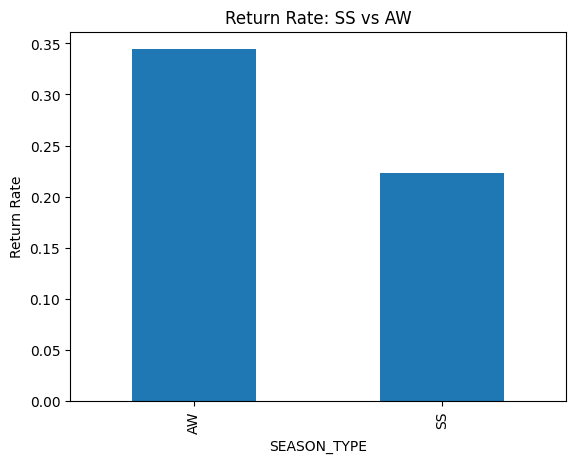

In [23]:
import matplotlib.pyplot as plt

# Return Rate: Sommer vs Winter
season_return = agg.groupby("SEASON_TYPE")["RETURNED"].mean()

season_return.plot(kind="bar")
plt.title("Return Rate: SS vs AW")
plt.ylabel("Return Rate")
plt.show()

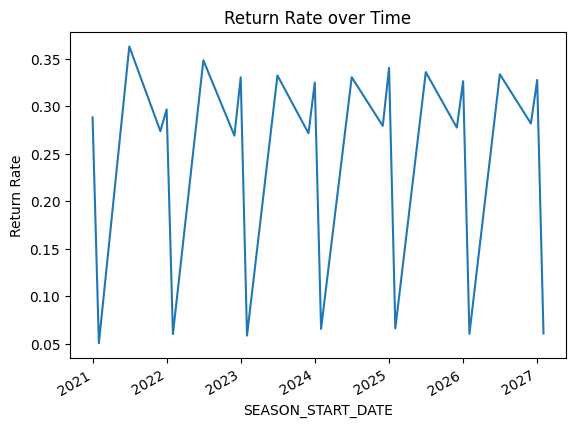

In [ ]:
# Timeline Returnrate throughout Saesons

agg["SEASON_START_DATE"] = pd.to_datetime(agg["SEASON_START_DATE"])

timeline = agg.groupby("SEASON_START_DATE")["RETURNED"].mean().sort_index()

timeline.plot()
plt.title("Return Rate over Time")
plt.ylabel("Return Rate")
plt.show()

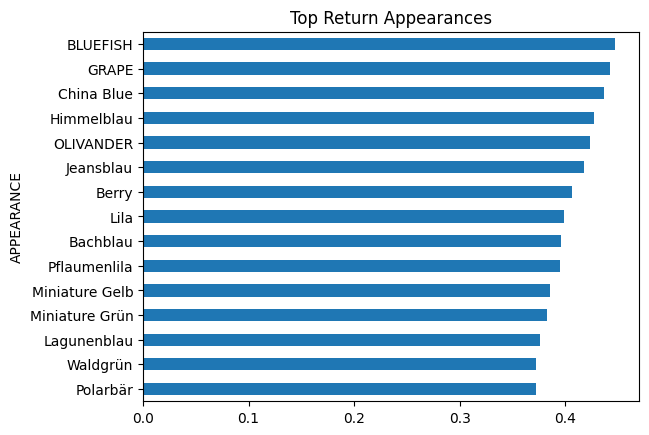

In [ ]:
# Most returnes Appearances

appearance_returns = agg.groupby("APPEARANCE")["RETURNED"].mean().sort_values()

appearance_returns.tail(15).plot(kind="barh")
plt.title("Top Return Appearances")
plt.show()

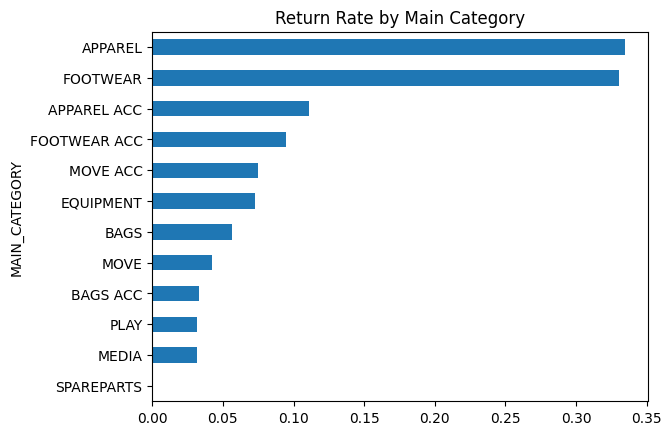

In [ ]:
# Main Cat Returns

agg.groupby("MAIN_CATEGORY")["RETURNED"].mean().sort_values().plot(kind="barh")
plt.title("Return Rate by Main Category")
plt.show()

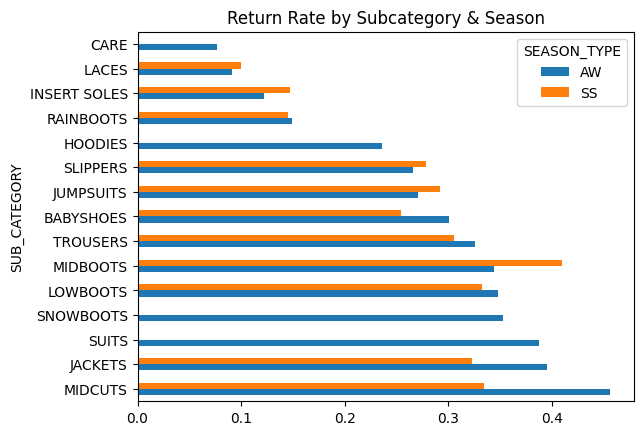

In [ ]:
# Sub Cat + Season

pivot = agg.pivot_table(
    values="RETURNED",
    index="SUB_CATEGORY",
    columns="SEASON_TYPE",
    aggfunc="mean"
)

pivot.sort_values("AW", ascending=False).head(15).plot(kind="barh")
plt.title("Return Rate by Subcategory & Season")
plt.show()

In [ ]:
# viel gekauft +  viel reture

purchase_vs_return = agg.groupby("MAIN_CATEGORY").agg({
    "QUANTITY": "sum",
    "RETURNED": "mean"
})

print(purchase_vs_return.sort_values("RETURNED", ascending=False))

               QUANTITY  RETURNED
MAIN_CATEGORY                    
APPAREL            5355  0.334461
FOOTWEAR         758377  0.330443
APPAREL ACC       30983  0.110623
FOOTWEAR ACC       3656  0.094432
MOVE ACC          23891  0.074792
EQUIPMENT         25802  0.072617
BAGS             270297  0.056433
MOVE               3625  0.042201
BAGS ACC          34574  0.032806
PLAY               2681  0.031809
MEDIA              4124  0.031674
SPAREPARTS            7  0.000000


In [ ]:
footwear = agg[
    agg["MAIN_CATEGORY"].isin(["FOOTWEAR", "FOOTWEAR ACC"])
]
footwear_returns = footwear[
    (footwear["RETURNED"] == 1) &
    (footwear["RETURN_REASON_CODE"].notna()) &
    (footwear["RETURN_REASON_CODE"] != "")
]

reasons = footwear_returns["RETURN_REASON_CODE"].str.split(", ")

reasons_exploded = reasons.explode()
reason_counts = reasons_exploded.value_counts()
print(reason_counts.head(10))

RETURN_REASON_CODE
RET_100      356565
DEFEKT         6530
UZ             4313
NF             1086
FL              492
AV              317
VERLUST         159
UL              153
FALSCH           39
FEHLMENGE        14
Name: count, dtype: int64


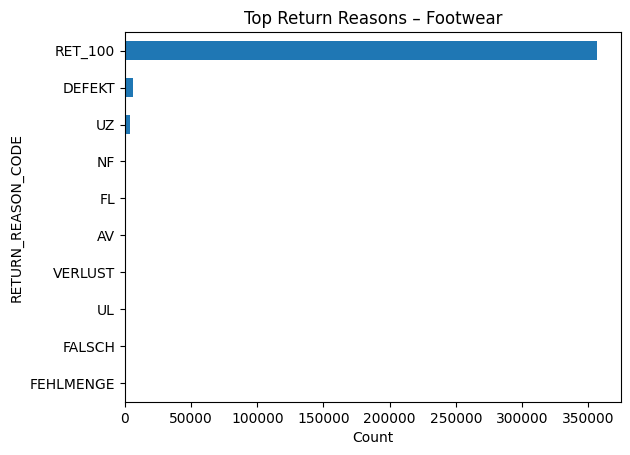

In [ ]:
# Absolut

reason_counts.head(10).plot(kind="barh")
plt.title("Top Return Reasons – Footwear")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.show()

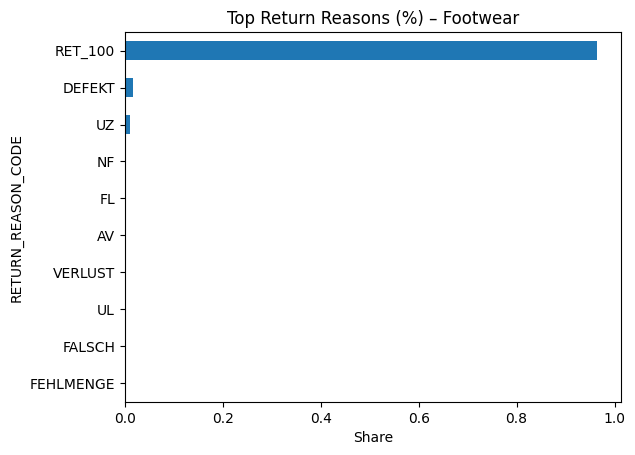

In [ ]:
# Prozent

reason_share = reason_counts / reason_counts.sum()

reason_share.head(10).plot(kind="barh")
plt.title("Top Return Reasons (%) – Footwear")
plt.xlabel("Share")
plt.gca().invert_yaxis()
plt.show()

C:\Users\vanes\AppData\Local\Temp\ipykernel_21264\334970814.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  footwear_returns["SEASON_TYPE"] = footwear_returns["SEASON"].str[:2]


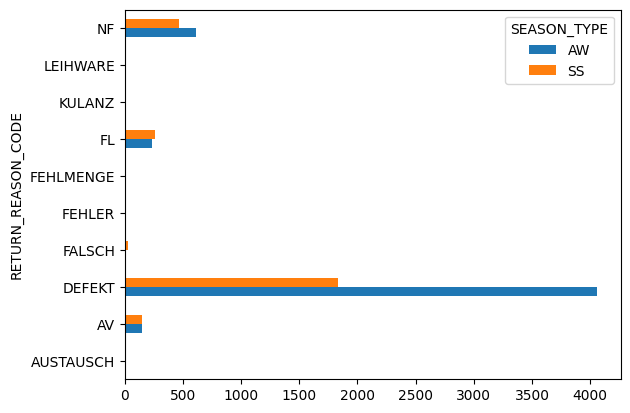

In [ ]:
# Season Split

footwear_returns["SEASON_TYPE"] = footwear_returns["SEASON"].str[:2]

pivot = footwear_returns.explode("RETURN_REASON_CODE").pivot_table(
    index="RETURN_REASON_CODE",
    columns="SEASON_TYPE",
    aggfunc="size",
    fill_value=0
)

pivot.head(10).plot(kind="barh")
plt.show()

In [32]:
agg_clean = agg[agg["QUANTITY"] >= 0].copy()

agg["DISCOUNT_RATE"] = 1 - (agg["NET_AMOUNT"] / agg["UVP"]).replace(0, pd.NA)

agg["PRICE_DIFF_TO_UVP"] = agg["UVP"] - agg["NET_AMOUNT"]

agg[["NET_AMOUNT", "UVP", "DISCOUNT_RATE", "PRICE_DIFF_TO_UVP"]].describe()

,NET_AMOUNT,UVP,PRICE_DIFF_TO_UVP
count,1.551811e+06,1.478361e+06,1.478361e+06
mean,3.672212e+01,6.808456e+01,3.170436e+01
std,3.059131e+01,2.911838e+01,3.166045e+01
min,-1.722400e+02,4.100000e-01,-1.180650e+03
25%,1.000000e-02,4.499000e+01,9.800000e+00
50%,3.781000e+01,6.499000e+01,1.597000e+01
75%,5.874000e+01,8.999000e+01,4.537000e+01
max,1.680640e+03,4.999900e+02,4.999900e+02


<Axes: >

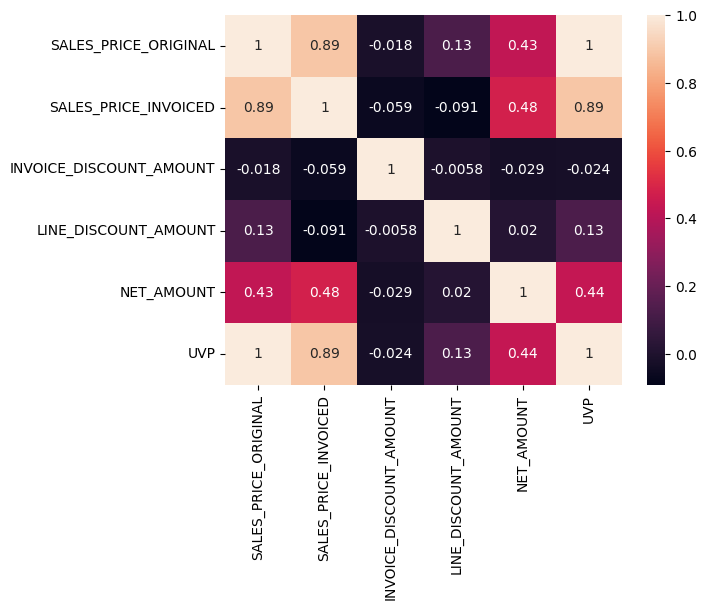

In [35]:
import seaborn as sns

corr = agg[[
    "SALES_PRICE_ORIGINAL",
    "SALES_PRICE_INVOICED",
    "INVOICE_DISCOUNT_AMOUNT",
    "LINE_DISCOUNT_AMOUNT",
    "NET_AMOUNT",
    "UVP"
]].corr()

sns.heatmap(corr, annot=True)

In [38]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

def stepwise_logistic_selection(
    X,
    y,
    p_enter=0.05,
    p_remove=0.10,
    corr_threshold=0.80,
    max_iter=100
):
    X = X.copy()
    y = y.copy()

    # Nur numerische Spalten
    X = X.select_dtypes(include=[np.number])

    # NaN / Inf entfernen
    data = pd.concat([X, y.rename("target")], axis=1)
    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    X = data.drop(columns="target")
    y = data["target"]

    selected = []
    remaining = list(X.columns)

    for _ in range(max_iter):
        changed = False

        # Forward Step
        pvals = {}

        for col in remaining:
            test_features = selected + [col]

            # Korrelationscheck
            if len(test_features) > 1:
                corr = X[test_features].corr().abs()
                upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
                if (upper > corr_threshold).any().any():
                    continue

            try:
                model = sm.Logit(y, sm.add_constant(X[test_features])).fit(disp=False)
                pvals[col] = model.pvalues[col]
            except Exception:
                continue

        if pvals:
            best_feature = min(pvals, key=pvals.get)
            best_pval = pvals[best_feature]

            if best_pval < p_enter:
                selected.append(best_feature)
                remaining.remove(best_feature)
                changed = True
                print(f"Added: {best_feature} | p={best_pval:.4f}")

        # Backward Step
        if selected:
            try:
                model = sm.Logit(y, sm.add_constant(X[selected])).fit(disp=False)
                feature_pvals = model.pvalues.drop("const", errors="ignore")

                worst_feature = feature_pvals.idxmax()
                worst_pval = feature_pvals.max()

                if worst_pval > p_remove:
                    selected.remove(worst_feature)
                    remaining.append(worst_feature)
                    changed = True
                    print(f"Removed: {worst_feature} | p={worst_pval:.4f}")

            except Exception:
                pass

        if not changed:
            break

    final_model = sm.Logit(y, sm.add_constant(X[selected])).fit(disp=False)

    return selected, final_model

In [37]:
agg.columns.tolist()

['ORDER_NO',
 'ITEM_NO',
 'QUANTITY',
 'NET_AMOUNT',
 'SALES_PRICE_ORIGINAL',
 'SALES_PRICE_INVOICED',
 'UVP',
 'INVOICE_DISCOUNT_AMOUNT',
 'LINE_DISCOUNT_AMOUNT',
 'SEASON',
 'SEASON_START_DATE',
 'SEASON_END_DATE',
 'PRODUCT_TYPE',
 'SIZE',
 'APPEARANCE',
 'MAIN_CATEGORY',
 'SUB_CATEGORY',
 'IS_RETURN_INCL_INDIRECT',
 'RETURN_REASON_CODE_CLEAN',
 'DAYS_ORDER_TO_INVOICE',
 'SEASON_ORDER_DATE',
 'EDGE_CASE',
 'RETURNED',
 'SEASON_TYPE',
 'DISCOUNT_RATE',
 'PRICE_DIFF_TO_UVP']

In [ ]:
print(agg["SEASON_TYPE"].nunique())
print(agg["MAIN_CATEGORY"].nunique())
print(agg["APPEARANCE"].nunique())
print(agg["PRODUCT_TYPE"].nunique())

2
12


In [44]:
num_cols = [
    "DISCOUNT_RATE",
    "PRICE_DIFF_TO_UVP",
    "DAYS_ORDER_TO_INVOICE",
    "NET_AMOUNT"
]

X_num = agg[num_cols].apply(pd.to_numeric, errors="coerce").astype("float32")

cat_cols = [
    "SEASON_TYPE",
    "MAIN_CATEGORY"
]

X_cat = pd.get_dummies(
    agg[cat_cols],
    drop_first=True,
    dtype="int8"
)

X = pd.concat([X_num, X_cat], axis=1)

y = agg["RETURNED"].astype("int8")

data = pd.concat([X, y.rename("RETURNED")], axis=1)
data = data.replace([np.inf, -np.inf], np.nan).dropna()

X = data.drop(columns="RETURNED")
y = data["RETURNED"]

print(X.shape)
print(X.dtypes.value_counts())

(1165619, 16)
int8       12
float32     4
Name: count, dtype: int64


In [45]:
selected_features, final_model = stepwise_logistic_selection(X, y)
print(selected_features)
print(final_model.summary())

c:\Users\vanes\miniconda3\envs\capstone-2026\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Added: DISCOUNT_RATE | p=0.0000
Added: MAIN_CATEGORY_FOOTWEAR | p=0.0000
Added: DAYS_ORDER_TO_INVOICE | p=0.0000
Added: NET_AMOUNT | p=0.0000
Added: SEASON_TYPE_SS | p=0.0000
Added: MAIN_CATEGORY_PLAY | p=0.0000
Added: MAIN_CATEGORY_BAGS | p=0.0011
Added: MAIN_CATEGORY_MOVE ACC | p=0.0131
['DISCOUNT_RATE', 'MAIN_CATEGORY_FOOTWEAR', 'DAYS_ORDER_TO_INVOICE', 'NET_AMOUNT', 'SEASON_TYPE_SS', 'MAIN_CATEGORY_PLAY', 'MAIN_CATEGORY_BAGS', 'MAIN_CATEGORY_MOVE ACC']
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:              1165619
Model:                          Logit   Df Residuals:                  1165610
Method:                           MLE   Df Model:                            8
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                  0.9871
Time:                        16:57:50   Log-Likelihood:                -3586.5
converged:                       True   LL-Null:                 